# WASP-52b: EXHALE model vs. observed He\,10830 and H$\alpha$

Simple **overplot, no fitting**. EXHALE escape model: $\epsilon$\,Eri MUSCLES SED
scaled to $a=0.0272$ au, Yan et al. (2022) parameters, pressure (1 $\mu$bar) base
BC, Roche (tidal) potential extended to 10 $R_p$. Transmission from `TPM.py`.

Grid: 2 XUV levels ($F_{\rm XUV}=1.0\times,\,0.5\times$ the $\epsilon$\,Eri fiducial)
$\times$ 3 compositions (solar H/He, He-poor 98/2, solar + C/N/O metals).

**Wavelength frame.** The He\,10830 \emph{observation} is tabulated in
\textbf{vacuum}; the \texttt{TPM.py} model and its NIST He-triplet line centers are
in \textbf{air}. Following Yan et al. (2022), the He observation is converted
vacuum$\to$air (Morton 2000 / IAU) so both are on the same air scale. H$\alpha$ is
already in air on both sides.

**Sign conventions** differ between the two observation files, so each panel matches
its own data: He is \emph{excess absorption} (\textbf{positive} $=$ absorption);
H$\alpha$ is a \emph{transit spectrum} (\textbf{negative} dip $=$ absorption).

In [1]:
import os, numpy as np, matplotlib.pyplot as plt

HERE = os.path.abspath('.')
OBS  = '/home/kiseon/Exoplanetary_Atmosphere/WASP-52b'

# vacuum -> air wavelength conversion (Morton 2000 / IAU standard), lam in Angstrom.
def vac_to_air(lam_vac):
    s = 1.0e4 / lam_vac
    n = 1.0 + 0.0000834254 + 0.02406147/(130.0 - s**2) + 0.00015998/(38.9 - s**2)
    return lam_vac / n

# observations (native sign of each file)
he      = np.loadtxt(os.path.join(OBS, 'wasp52_He10830_trans_spec.dat'))   # lam_VAC, exc_abs[%](+=abs), sig
he_lair = vac_to_air(he[:, 0])                                             # -> air, to match the model
ha      = np.loadtxt(os.path.join(OBS, 'WASP52b_Halpha_transpec_0p10_AA_binned.txt'))  # lam_air, TS(-=abs), e_TS, model

# model grid: (folder, label, color, linestyle)
cases = [
    ('fxuv1p0_solar',     r'solar, $1.0\times$',        'C0', '-'),
    ('fxuv0p5_solar',     r'solar, $0.5\times$',        'C0', '--'),
    ('fxuv1p0_he98',      r'He 98/2, $1.0\times$',      'C1', '-'),
    ('fxuv0p5_he98',      r'He 98/2, $0.5\times$',      'C1', '--'),
    ('fxuv1p0_solar_met', r'solar+metals, $1.0\times$', 'C2', '-'),
    ('fxuv0p5_solar_met', r'solar+metals, $0.5\times$', 'C2', '--'),
]

# load TPM model curve -> (lambda_air[A], excess absorption[%] = (1-T)*100 >= 0)
# from the planet-rotation + instrument-convolved transmission (column 3).
def load_model(folder, line):
    f = os.path.join(HERE, folder, 'tpm_%s.txt' % line)
    if not os.path.exists(f):
        return None
    d = np.loadtxt(f)
    return d[:, 0], (1.0 - d[:, 3]) * 100.0

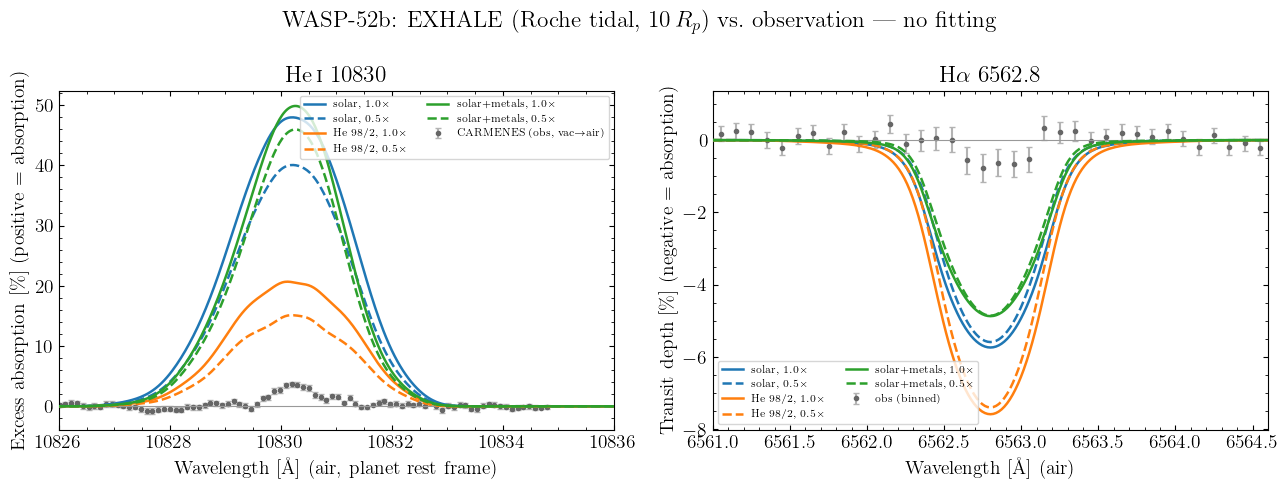

saved compare_WASP-52b.png


In [2]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# ---- He I 10830 : excess-absorption convention (positive = absorption), AIR scale ----
ax[0].errorbar(he_lair, he[:,1], yerr=he[:,2], fmt='o', ms=3, color='0.4',
               ecolor='0.7', capsize=2, label='CARMENES (obs, vac$\\to$air)', zorder=1)
for folder, lab, col, ls in cases:
    m = load_model(folder, 'He10830')
    if m is None:
        print('missing He model:', folder); continue
    ax[0].plot(m[0], m[1], color=col, ls=ls, lw=1.8, label=lab, zorder=3)   # positive
ax[0].axhline(0, color='0.6', lw=0.8)
ax[0].set_xlim(10826.0, 10836.0)
ax[0].set_xlabel(r'Wavelength [\AA] (air, planet rest frame)')
ax[0].set_ylabel(r'Excess absorption [\%]  (positive $=$ absorption)')
ax[0].set_title(r'He\,\textsc{i} 10830')
ax[0].legend(fontsize=7.5, ncol=2)

# ---- H-alpha : transit-spectrum convention (negative dip = absorption), AIR scale ----
ax[1].errorbar(ha[:,0], ha[:,1]*100.0, yerr=ha[:,2]*100.0, fmt='o', ms=3, color='0.4',
               ecolor='0.7', capsize=2, label='obs (binned)', zorder=1)
for folder, lab, col, ls in cases:
    m = load_model(folder, 'Halpha')
    if m is None:
        print('missing Ha model:', folder); continue
    ax[1].plot(m[0], -m[1], color=col, ls=ls, lw=1.8, label=lab, zorder=3)  # negative dip
ax[1].axhline(0, color='0.6', lw=0.8)
ax[1].set_xlim(6561.0, 6564.6)
ax[1].set_xlabel(r'Wavelength [\AA] (air)')
ax[1].set_ylabel(r'Transit depth [\%]  (negative $=$ absorption)')
ax[1].set_title(r'H$\alpha$ 6562.8')
ax[1].legend(fontsize=7.5, ncol=2)

fig.suptitle(r'WASP-52b: EXHALE (Roche tidal, 10\,$R_p$) vs.\ observation --- no fitting')
fig.tight_layout()
fig.savefig('compare_WASP-52b.png', dpi=140)
plt.show()
print('saved compare_WASP-52b.png')

## Atmospheric structure: temperature, velocity, density

Converged EXHALE `_adv` profiles for the 6-case grid (color $=$ composition,
line style $=$ $F_{\rm XUV}$). Radius in planet radii out to the 10 $R_p$ Roche
(tidal) outer boundary; the He\,10830 / H$\alpha$ absorbing layers and the
extended outer wind (which dominates the impact-parameter transit depth) are both
visible here.

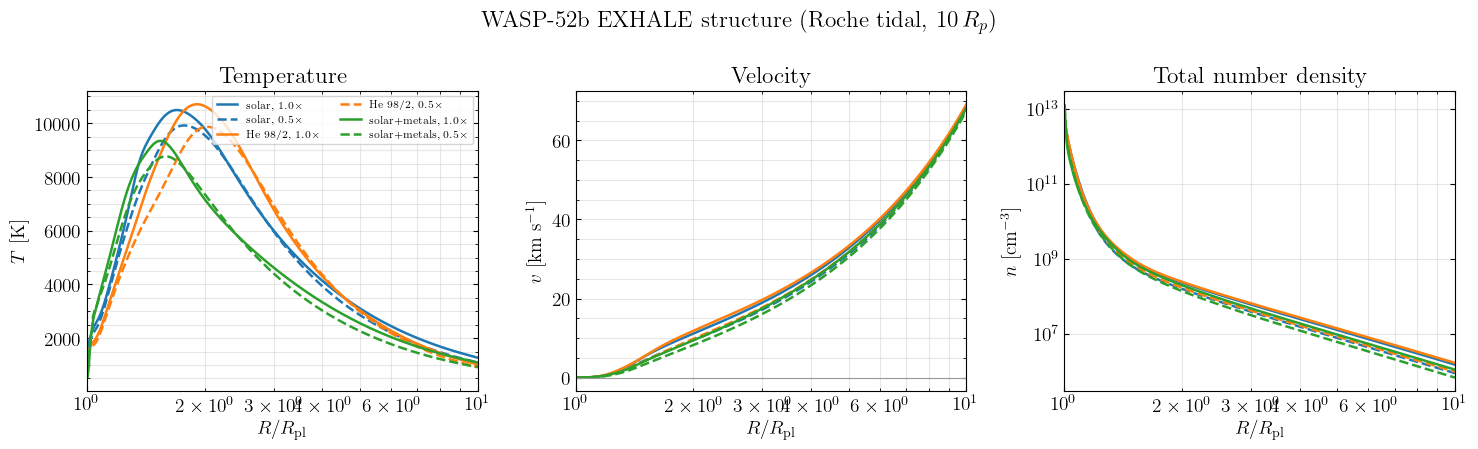

In [3]:
# T, v, n profiles for all 6 cases. Hydro_ioniz_adv columns: r[Rp], n[cm^-3],
# v[cm/s], p[erg/cm^3], T[K], heat, cool.
fig, ax = plt.subplots(1, 3, figsize=(15, 4.6))
for folder, lab, col, ls in cases:
    f = os.path.join(HERE, folder, 'output', 'Hydro_ioniz_adv.txt')
    if not os.path.exists(f):
        print('missing profile:', folder); continue
    d = np.loadtxt(f)
    r, n, v, T = d[:,0], d[:,1], d[:,2], d[:,4]
    kw = dict(color=col, ls=ls, lw=1.8, label=lab)
    ax[0].plot(r, T, **kw)
    ax[1].plot(r, v/1e5, **kw)
    ax[2].semilogy(r, n, **kw)
ax[0].set_ylabel(r'$T$ [K]');                 ax[0].set_title('Temperature')
ax[1].set_ylabel(r'$v$ [km s$^{-1}$]');       ax[1].set_title('Velocity')
ax[1].axhline(0, color='0.6', lw=0.8)
ax[2].set_ylabel(r'$n$ [cm$^{-3}$]');         ax[2].set_title('Total number density')
for a in ax:
    a.set_xlabel(r'$R/R_{\rm pl}$')
    a.set_xscale('log')
    a.set_xlim(1, 10)
    a.grid(alpha=0.3, which='both')
ax[0].legend(fontsize=7.5, ncol=2)
fig.suptitle(r'WASP-52b EXHALE structure (Roche tidal, 10\,$R_p$)')
fig.tight_layout()
plt.show()